 
<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL:** 

**EXAMEN 2.**
===
EZAU FARIDH TORRES TORRES.
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 23/05/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                                  # library for numerical operations.
import matplotlib.pyplot as plt                     # library for plotting.
import torch                                        # library for tensor operations.
from nltk.tokenize import TweetTokenizer            # library for tweet tokenization.
from nltk.corpus import stopwords                   # library for stopwords.
stopwords_es = set(stopwords.words('spanish'))      # set of spanish stopwords.
import os                                           # library for operating system.
import time                                         # library for time.
from typing import Tuple, Callable, List, Optional  # library for typing.
import random                                       # library for random numbers.
import pandas as pd                                 # library for data manipulation.
from collections import defaultdict, Counter        # library for collections.
from tqdm import tqdm                               # library for progress bar.
import torch.nn as nn                               # library for neural network operations.
import torch.nn.functional as F                     # library for functional operations.
from torch.utils.data import (DataLoader,           # library for data loading.
                              Dataset)              # library for dataset.
from sklearn.metrics import (confusion_matrix,      # library for evaluation.
                             classification_report) # library for evaluation.                   
import csv                                          # library for csv operations.
from torch import optim                             # for neural networks.
from colorama import Fore, Style                    # library for colored text.
import seaborn as sns                               # library for data visualization.
sns.set_style("darkgrid")                           # set style for seaborn.
import xml.etree.ElementTree as ET                  # library for xml parsing.
np.random.seed(0)                                   # seed for reproducibility.
random.seed(0)                                      # seed for reproducibility.
torch.manual_seed(0)                                # seed for reproducibility.
torch.backends.cudnn.benchmark = False              # reproducibility.

In [2]:
def load_data_and_labels(folder_path: str) -> Tuple[List[Tuple[str, str]], List[Tuple[str, str]]]:
    """
    Load data and labels from the specified folder. 
    
    Parameters
    ----------
    folder_path : str
        Path to the folder containing the XML files and truth.txt file.

    Returns
    -------
    data : List[Tuple[str, str]]
        List of tuples containing user IDs and their corresponding text.
    labels : List[Tuple[str, str]]
        List of labels corresponding to the user IDs.
    """
    # Load labels from truth.txt
    if os.path.exists(os.path.join(folder_path, 'truth.txt')):
        truth_path = os.path.join(folder_path, 'truth.txt')
    else:
        truth_path = os.path.join(folder_path, 'truth_order.txt')
    if not os.path.exists(truth_path):
        raise FileNotFoundError(f"Truth file not found in {folder_path}.")

    id_to_label = {} # Dictionary to store the labels.

    # Read the truth file and store the labels in a dictionary.
    with open(truth_path, 'r', encoding = 'utf-8') as f: # Open the file.
        for line in f:                                   # Read line by line.
            user_id, gender, country = line.strip().split(':::')             # Unpack the parts.
            id_to_label[user_id] = (gender, country)     # Store the labels in the dictionary.

    data = []   # (user_id, tweet)
    labels = [] # (gender, country)

    for filename in os.listdir(folder_path):                # Iterate over the files in the folder.
        if filename.endswith('.xml'):                       # Iterate over the XML files in the folder.
            user_id = filename.replace('.xml', '')          # Extract user ID from filename.
            file_path = os.path.join(folder_path, filename) # Construct the full file path.
            
            # Parse the XML file and extract the text.
            tree = ET.parse(file_path)             
            root = tree.getroot() 
            documents = root.find('documents')

            # Check if the documents element exists.
            for doc in documents.findall('document'):
                text = doc.text
                data.append((user_id, text))          
                labels.append(id_to_label[user_id])  

    return data, labels

def explore_data(data: List[Tuple[str, str]], labels: List[str], dataset_name: str) -> None:
    """
    Explore the data and print statistics.
    """
    user_ids = [uid for uid, _ in data]
    unique_users = set(user_ids)
    tweets_per_user = defaultdict(list)
    for (uid, tweet), label in zip(data, labels):
        tweets_per_user[uid].append(tweet)
    num_tweets_por_usuario = [len(tweets) for tweets in tweets_per_user.values()]
    t_mean = np.mean(num_tweets_por_usuario)
    t_min = min(num_tweets_por_usuario)
    t_max = max(num_tweets_por_usuario)
    
    print(f'➤ Statistics for {dataset_name}')
    print(f'    Total tweets            : {len(data)}')
    print(f'    Total users             : {len(unique_users)}')
    print(f'    Average tweets per user : {t_mean:.2f}')
    print(f'    Minimum tweets per user : {t_min}')
    print(f'    Maximum tweets per user : {t_max}')
    print("")

In [3]:
# Load data and labels for training and validation sets.
data_train, labels_train = load_data_and_labels(folder_path = 'data/es_train')
data_val, labels_val     = load_data_and_labels(folder_path = 'data/es_val')
data_test, labels_test   = load_data_and_labels(folder_path = 'data/es_test')

print(f'Number of genres    : {len(set([label[0] for label in labels_train]))}')
print(f'Number of countries : {len(set([label[1] for label in labels_train]))}')
print("")
print('Example of tweet')
uid, tweet = data_train[7648]
label = labels_train[7648]
print(f'Tweet   : {tweet}')
print(f'User    : {uid}')
print(f'Gender  : {label[1]}')
print(f'Country : {label[0]}')
print("")

# Explore the data for training and validation sets.
explore_data(data_train, labels_train, 'Training')
explore_data(data_val, labels_val, 'Validation')
explore_data(data_test, labels_test, 'Test')

Number of genres    : 2
Number of countries : 7

Example of tweet
Tweet   : @FerAlvarez Claro que hay justicia deportiva, Magallanes y Caracas merecían la eliminación. Bien por @aguilasdelzulia  y @CardenalesDice
User    : f54e1a95965ea984606de6eec5d7cf32
Gender  : venezuela
Country : male

➤ Statistics for Training
    Total tweets            : 335998
    Total users             : 3360
    Average tweets per user : 100.00
    Minimum tweets per user : 99
    Maximum tweets per user : 100

➤ Statistics for Validation
    Total tweets            : 84000
    Total users             : 840
    Average tweets per user : 100.00
    Minimum tweets per user : 100
    Maximum tweets per user : 100

➤ Statistics for Test
    Total tweets            : 280000
    Total users             : 2800
    Average tweets per user : 100.00
    Minimum tweets per user : 100
    Maximum tweets per user : 100



In [4]:
def plot_distribution(labels_train: List[Tuple[str, str]], labels_val: List[Tuple[str, str]],
                      data_train: Optional[List[Tuple[str, str]]], data_val: Optional[List[Tuple[str, str]]],
                      plot_type: str) -> None:  
                  
    def annotate_bars(ax):
        for p in ax.patches:
            height = p.get_height()
            if not np.isnan(height) and height > 0:
                ax.text(p.get_x() + p.get_width() / 2., height + 1, int(height),
                        ha = "center", va = "bottom", fontsize = 9, weight = 'bold')
                
    fig, axs = plt.subplots(2, 2, figsize = (12, 8), sharey = 'row')

    if plot_type == 'tweets':
        df_train = pd.DataFrame(labels_train, columns = ["gender", "country"], index = range(1, len(labels_train)+1))
        df_val = pd.DataFrame(labels_val, columns = ["gender", "country"], index = range(1, len(labels_val)+1))

        gender_order  = ['female', 'male']
        country_order = sorted(df_train['country'].unique())
        
        fig.suptitle('Distribution of tweets of training and validation data', fontsize = 16, weight = 'bold')

        sns.countplot(data = df_train, x = "gender", ax = axs[0,0], hue = "gender", order = gender_order, hue_order = gender_order, palette = "YlGnBu_d")
        sns.countplot(data = df_train, x = "country", ax = axs[0,1], hue = "country", order = country_order, hue_order = country_order, palette = "Oranges_d")
        sns.countplot(data = df_val, x = "gender", ax = axs[1,0], hue = "gender", order = gender_order, hue_order = gender_order, palette = "YlGnBu_d")
        sns.countplot(data = df_val, x = "country", ax = axs[1,1], hue = "country", order = country_order, hue_order = country_order, palette = "Oranges_d")

        axs[0,0].set_ylabel("Tweets")
        axs[1,0].set_ylabel("Tweets")
        axs[0,1].set_ylabel("")
        axs[1,1].set_ylabel("")

    elif plot_type == 'users':
        if data_train is None or data_val is None:
            raise ValueError("data_train and data_val are required for 'users' plot_type.")

        user_to_label_train = {user_id: label for (user_id, _), label in zip(data_train, labels_train)}
        user_to_label_val   = {user_id: label for (user_id, _), label in zip(data_val, labels_val)}

        df_train_users = pd.DataFrame(user_to_label_train.values(), columns = ["gender", "country"])
        df_val_users   = pd.DataFrame(user_to_label_val.values(), columns = ["gender", "country"])

        gender_counts_train  = df_train_users["gender"].value_counts().reindex(["female", "male"])
        gender_counts_val    = df_val_users["gender"].value_counts().reindex(["female", "male"])
        country_order        = sorted(set(df_train_users["country"]) | set(df_val_users["country"]))
        country_counts_train = df_train_users["country"].value_counts().reindex(country_order)
        country_counts_val   = df_val_users["country"].value_counts().reindex(country_order)

        fig.suptitle('Distribution of users in training and validation data', fontsize = 16, weight = 'bold')

        sns.barplot(x = gender_counts_train.index, y = gender_counts_train.values, hue = gender_counts_train.index, ax = axs[0,0], palette = "YlGnBu_d")
        sns.barplot(x = country_counts_train.index, y = country_counts_train.values, hue = country_counts_train.index, ax = axs[0,1], palette = 'Greens_d')
        sns.barplot(x = gender_counts_val.index, y = gender_counts_val.values, hue = gender_counts_val.index, ax = axs[1,0], palette = "YlGnBu_d")
        sns.barplot(x = country_counts_val.index, y = country_counts_val.values, hue = country_counts_val.index, ax = axs[1,1], palette = 'Greens_d')

        axs[0,0].set_ylabel("Users")
        axs[1,0].set_ylabel("Users")
        axs[0,1].set_ylabel("")
        axs[1,1].set_ylabel("")

    else:
        raise ValueError("plot_type must be 'tweets' or 'users'.")

    # Etiquetas comunes
    for ax in axs.flatten():
        ax.set_xlabel("")
        annotate_bars(ax)

    fig.text(0.71, 0.02, 'Distribution by country', fontsize = 12, weight = 'bold')
    fig.text(0.24, 0.02, 'Distribution by gender', fontsize = 12, weight = 'bold')
    fig.text(0.02, 0.73, 'Training Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')
    fig.text(0.02, 0.29, 'Validation Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')

    plt.tight_layout(rect = [0.04, 0.04, 1, 1])
    plt.show()

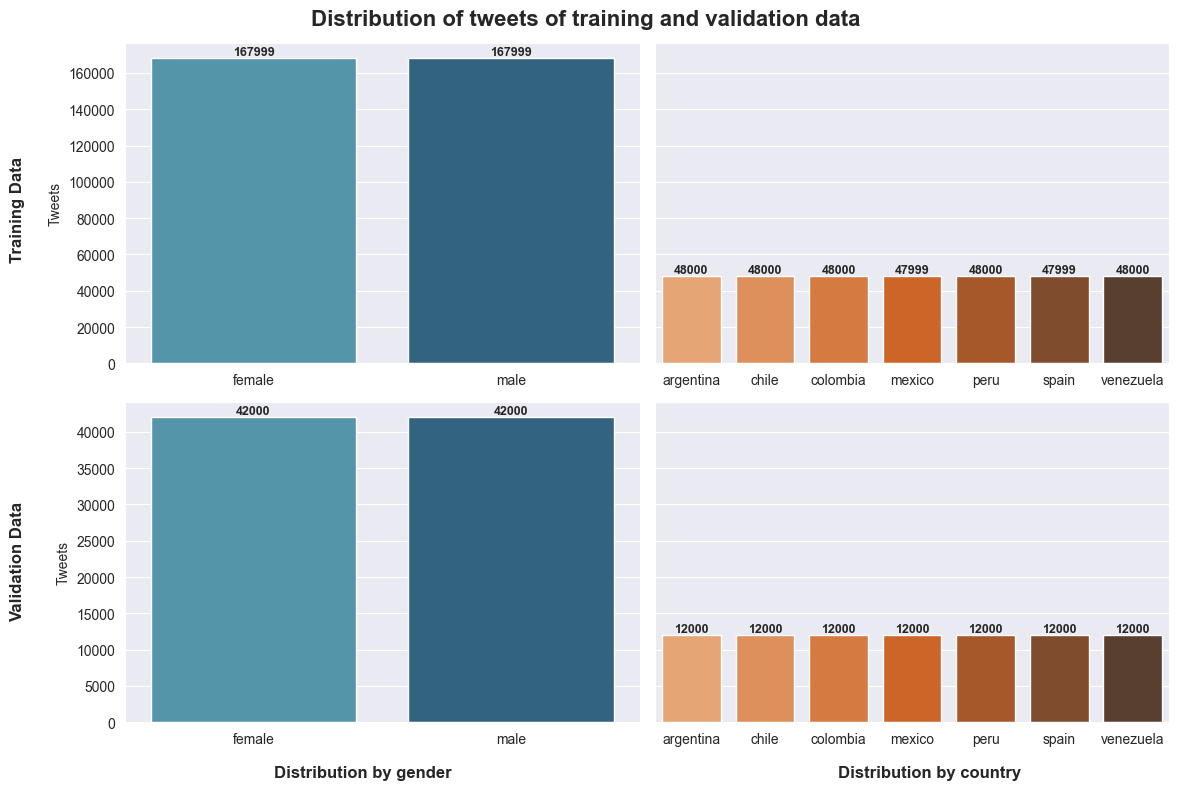

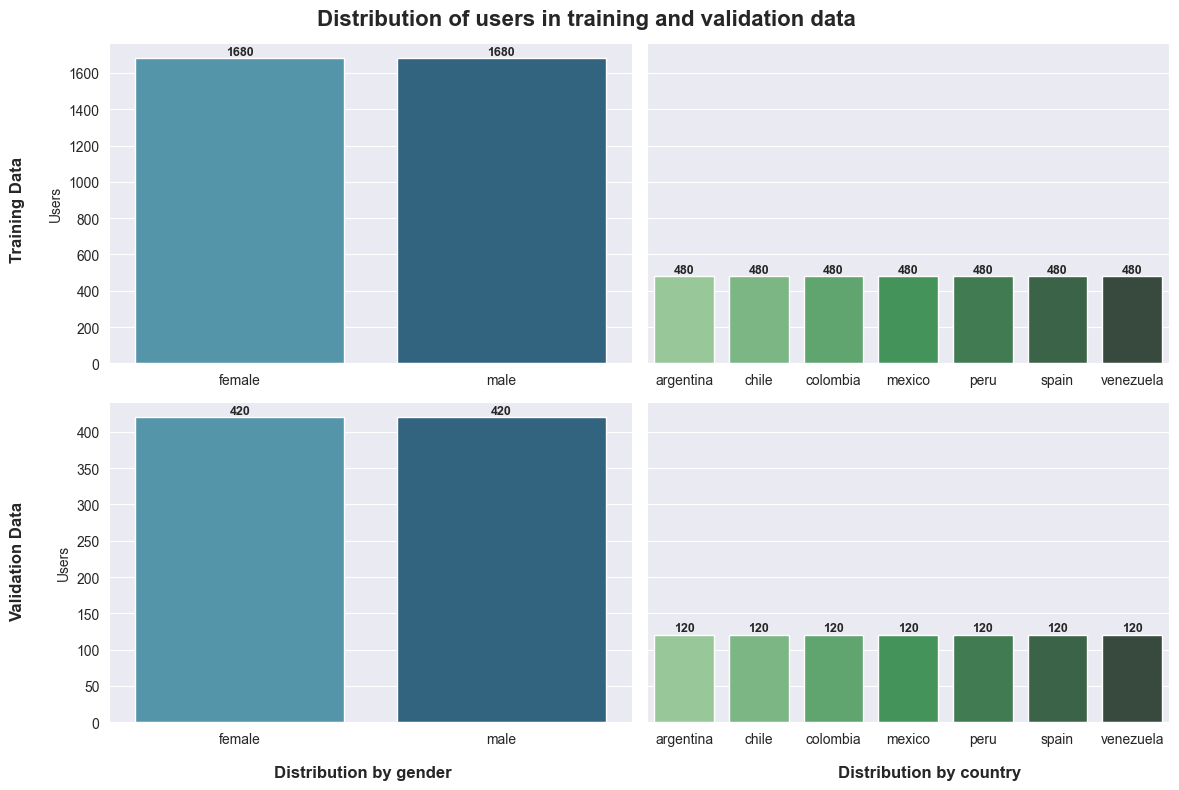

In [5]:
plot_distribution(labels_train, labels_val, data_train, data_val,  plot_type = 'tweets')
plot_distribution(labels_train, labels_val, data_train, data_val,  plot_type = 'users')

In [6]:
df_train = pd.DataFrame(labels_train, columns = ["gender", "country"], index = range(1, len(labels_train)+1))
df_val = pd.DataFrame(labels_val, columns = ["gender", "country"], index = range(1, len(labels_val)+1))

gender_to_id = {gender: idx for idx, gender in enumerate(df_train["gender"].unique())}
country_to_id = {country: idx for idx, country in enumerate(sorted(df_train["country"].unique()))}

print("Gender Map  :", gender_to_id)
print("Country Map :", country_to_id)

Gender Map  : {'female': 0, 'male': 1}
Country Map : {'argentina': 0, 'chile': 1, 'colombia': 2, 'mexico': 3, 'peru': 4, 'spain': 5, 'venezuela': 6}


In [7]:
class AuthorProfilingDataset(Dataset):
    def __init__(self, corpus: List[Tuple[str, str]], labels: Optional[List[Tuple[str, str]]] = None,
                 tokenizer: Callable = None, remove_stopwords: bool = False, stopwords_set: set = None,
                 gender_to_id: dict = None, country_to_id: dict = None,
                 is_test: bool = False):
        
        # Initialize the dataset with the corpus and labels.
        self.corpus = corpus
        self.labels = labels
        self.is_test = is_test
        self.gender_to_id = gender_to_id
        self.country_to_id = country_to_id
        self.id_to_gender = {v: k for k, v in gender_to_id.items()}
        self.id_to_country = {v: k for k, v in country_to_id.items()}

        if not is_test:
            assert labels is not None, "Labels must be provided for training and validation datasets."

        # Load vocabulary and embeddings.
        self.vocab, self.emb_mat = self.load_vocab_embeddings()
        self.user_to_tweets, self.user_to_label, self.user_ids = self.build_user_index()
       
        # Tokenizer for text processing and additional parameters.
        self.tokenizer = tokenizer if tokenizer else TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)
        self.remove_stopwords = remove_stopwords
        self.stopwords_set = stopwords_set

    @staticmethod
    def load_vocab_embeddings(path: str = 'data/word2vec_col.txt') -> Tuple[dict, np.ndarray]:
        """
        Load the vocabulary and pre-trained embeddings. It uses the word2vec model. The embeddings are
        stored in a file called 'word2vec_col.txt'.

        Returns
        -------
        vocab : dict
            A dictionary mapping words to their corresponding indices.
        emb_mat : np.ndarray
            A matrix of shape (vocab_size, embedding_dim) containing the word embeddings.
        """
        embeddings_list = []
        vocab = {}
        with open(path, 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk.
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector.
        vocab['pad'] = 0
        vocab['unk'] = 1
        return vocab, np.vstack(embeddings_list)

    def build_user_index(self) -> Tuple[dict, dict, List[str]]:
        user_to_tweets = {}
        user_to_label = {}

        for (user_id, tweet), label in zip(self.corpus, self.labels or [(None, None)] * len(self.corpus)):
            if user_id not in user_to_tweets:
                user_to_tweets[user_id] = []
                if not self.is_test:
                    user_to_label[user_id] = label
            user_to_tweets[user_id].append(tweet)

        user_ids = list(user_to_tweets.keys())
        return user_to_tweets, user_to_label, user_ids

    def preprocessed_text(self, text: str) -> List[int]:
        words = self.tokenizer.tokenize(text.lower())
        if self.remove_stopwords:
            words = [word for word in words if word not in self.stopwords_set]
        word_ids = [self.vocab.get(word, self.vocab['unk']) for word in words]
        return word_ids

    def __len__(self) -> int:
        return len(self.user_ids)

    def __getitem__(self, index: int):
        user_id = self.user_ids[index]        # Get user ID.
        tweets = self.user_to_tweets[user_id] # Get tweets for the user.
        tweet_ids_list = [self.preprocessed_text(tweet) or [self.vocab['unk']] for tweet in tweets]

        if self.is_test:
            return tweet_ids_list, user_id

        gender, country = self.user_to_label[user_id]
        gender_id = self.gender_to_id[gender]
        country_id = self.country_to_id[country]

        return tweet_ids_list, gender_id, country_id

    @staticmethod
    def collate_fn(batch):
        pad_value = 0

        if len(batch[0]) == 3:
            padded_batch, labels_gender, labels_country = [], [], []

            max_tweets = max(len(tweets) for tweets, _, _ in batch)
            max_words = max(len(words) for tweets, _, _ in batch for words in tweets)

            for tweets, gender_id, country_id in batch:
                tweet_tensors = [
                    torch.tensor(words + [pad_value] * (max_words - len(words)), dtype=torch.long)
                    for words in tweets
                ]
                while len(tweet_tensors) < max_tweets:
                    tweet_tensors.append(torch.full((max_words,), pad_value, dtype=torch.long))
                padded_batch.append(torch.stack(tweet_tensors))
                labels_gender.append(gender_id)
                labels_country.append(country_id)

            return (torch.stack(padded_batch),
                    torch.tensor(labels_gender),
                    torch.tensor(labels_country))

        else:
            padded_batch, user_ids = [], []
            max_tweets = max(len(tweets) for tweets, _ in batch)
            max_words = max(len(words) for tweets, _ in batch for words in tweets)

            for tweets, user_id in batch:
                tweet_tensors = [
                    torch.tensor(words + [pad_value] * (max_words - len(words)), dtype=torch.long)
                    for words in tweets
                ]
                while len(tweet_tensors) < max_tweets:
                    tweet_tensors.append(torch.full((max_words,), pad_value, dtype=torch.long))
                padded_batch.append(torch.stack(tweet_tensors))
                user_ids.append(user_id)

            return torch.stack(padded_batch), user_ids

In [8]:
# Create the datasets.
train_dataset = AuthorProfilingDataset(
    corpus = data_train, labels = labels_train, gender_to_id  = gender_to_id, country_to_id = country_to_id)
val_dataset = AuthorProfilingDataset(
    corpus = data_val, labels = labels_val, gender_to_id = gender_to_id, country_to_id = country_to_id)
test_dataset = AuthorProfilingDataset(
    corpus = data_test, labels = labels_test, gender_to_id  = gender_to_id, country_to_id = country_to_id,
    is_test = True)

# Create the dataloaders.
batch_size = 8
train_dataloader = DataLoader(
    dataset = train_dataset, batch_size = batch_size, shuffle = True, collate_fn = train_dataset.collate_fn)
val_dataloader = DataLoader(
    dataset = val_dataset, batch_size = batch_size, shuffle = False,collate_fn = val_dataset.collate_fn)
test_dataloader = DataLoader( 
    dataset = test_dataset, batch_size = batch_size, shuffle = False, collate_fn = test_dataset.collate_fn)


In [9]:
batch = next(iter(train_dataloader))
print("Train batch shape :", batch[0].shape)
print("Labels shape      :", batch[1].shape)

Train batch shape : torch.Size([8, 100, 35])
Labels shape      : torch.Size([8])


# Model

In [10]:
class Attention(nn.Module):
    def __init__(self, hidden_size: int):
        """
        Attention mechanism. Computes a context-aware weighted average of encoder outputs using a learned context
        vector using the following equations of the paper:
            - Word-level: Eq. (5)-(7)
            - Sentence-level: Eq. (8)-(10)

        Parameters
        ----------
        hidden_size : int
            Dimensionality of the encoder outputs.
        """
        super(Attention, self).__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)            
        self.context_vector = nn.Parameter(torch.randn(hidden_size)) 

    def forward(self, encoder_outputs: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute attention-weighted sum of encoder outputs.

        Parameters
        ----------
        encoder_outputs : torch.Tensor
            Tensor of shape [batch, seq_len, hidden_size] from a BiGRU.

        Returns
        -------
        weighted_output : torch.Tensor
            The weighted sum of encoder outputs, shape [batch, hidden_size].
        attention_weights : torch.Tensor
            Attention weights for each input element, shape [batch, seq_len].
        """
        u = torch.tanh(self.linear(encoder_outputs))  
        attention_scores = torch.matmul(u, self.context_vector)  
        attention_weights = F.softmax(attention_scores, dim = 1) 
        weighted_output = torch.sum(encoder_outputs * attention_weights.unsqueeze(-1), dim = 1) 
        return weighted_output, attention_weights

class HierarchicalAttentionNet(nn.Module):
    """
    Hierarchical Attention Network for Author Profiling. This model uses a two-level attention mechanism to
    process tweets from users. The first level applies attention to the words in each tweet, and the second
    level applies attention to the tweets of each user. The final output is a classification of the user into
    one of the countries. Architecture components:
        - Word-level BiGRU + attention (per tweet) — Eq. (1)-(7)
        - Tweet-level BiGRU + attention (per user) — Eq. (1)-(10)
        - Final classifier — Eq. (11)

    Parameters
    ----------
    emb_dim : int
        Dimensionality of word embeddings.
    word_hidden_size : int
        Hidden size of the word-level GRU (per direction).
    tweet_hidden_size : int
        Hidden size of the tweet-level GRU (per direction).
    num_classes : int
        Number of output classes (e.g., countries).
    emb_matrix : np.ndarray
        Pretrained embedding matrix to initialize the embedding layer.
    """
    def __init__(self, emb_dim: int, word_hidden_size: int, tweet_hidden_size: int, num_classes_gender: int,
                 num_classes_country: int, emb_matrix: np.ndarray):
        super().__init__()
        self.dropout = nn.Dropout(0.15)

        # Embedding layer using pretrained word2vec.
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype = torch.float32),
            freeze = False # Set to True if you want to freeze the embeddings.
        )

        # Word-level BiGRU encoder (per tweet).
        self.word_gru     = nn.GRU(
            input_size    = emb_dim,
            hidden_size   = word_hidden_size,
            batch_first   = True,
            bidirectional = True
        )

        # Word-level attention.
        self.word_attention = Attention(2 * word_hidden_size)

        # Tweet-level BiGRU encoder (per user).
        self.tweet_gru    = nn.GRU(
            input_size    = 2 * word_hidden_size,
            hidden_size   = tweet_hidden_size,
            batch_first   = True,
            bidirectional = True
        )

        # Tweet-level attention.
        self.tweet_attention = Attention(2 * tweet_hidden_size)

        # Final classifier.
        self.classifier_gender = nn.Linear(2 * tweet_hidden_size, num_classes_gender)
        self.classifier_country = nn.Linear(2 * tweet_hidden_size, num_classes_country)

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the Hierarchical Attention Network.

        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape [batch_size, max_tweets, max_words], where each entry is a word index.

        Returns
        -------
        logits_gender : torch.Tensor
            Logits for gender classification, shape [batch_size, num_classes_gender].
        logits_country : torch.Tensor
            Logits for country classification, shape [batch_size, num_classes_country].
        word_attn_weights : torch.Tensor
            Attention weights at the word level, shape [batch_size * max_tweets, max_words].
        tweet_attn_weights : torch.Tensor
            Attention weights at the tweet level, shape [batch_size, max_tweets].
        """
        batch_size, num_tweets, num_words = x.size()

        # Flatten batch and tweets to process all tweets in parallel
        x = x.view(-1, num_words) 
        x = self.embedding(x)      

        word_output, _ = self.word_gru(x)                                              # Encode words using BiGRU.
        tweet_representations, word_attn_weights = self.word_attention(word_output)    # Word-level attention to get tweet representation.
        tweet_representations = tweet_representations.view(batch_size, num_tweets, -1) # Reshape.
        tweet_output, _ = self.tweet_gru(tweet_representations)                        # Encode tweets using BiGRU.
        doc_representation, tweet_attn_weights = self.tweet_attention(tweet_output)    # Tweet-level attention to get user/document representation

        # Apply the classifier.
        doc_representation = self.dropout(doc_representation)
        logits_gender = self.classifier_gender(doc_representation)
        logits_country = self.classifier_country(doc_representation)

        return logits_gender, logits_country, word_attn_weights, tweet_attn_weights


In [11]:
class Trainer:
    def __init__(
            self, model: nn.Module, epochs: int, train_dataset: Dataset, train_dataloader: DataLoader,
            val_dataloader: DataLoader, device: str, patience: int = 3, lambdas: Tuple[float, float] = (0.5, 0.5),
            lr: float = 1e-3, lr_patience: int = 3, weight_decay: float = 1e-4, lr_factor: float = 0.1,
            checkpoint_path: str = 'trained_model', checkpoint_filename: str = 'checkpoint.pth',
            model_init_args: dict = None
    ):
        # Initialize the trainer.
        self.model            = model.to(device)
        self.epochs           = epochs
        self.train_dataset    = train_dataset
        self.train_dataloader = train_dataloader
        self.val_dataloader   = val_dataloader
        self.device           = device
        self.patience         = patience
        self.lambdas          = lambdas
        self.model_init_args  = model_init_args

        # Checkpoint parameters.
        self.checkpoint_path     = checkpoint_path
        self.checkpoint_filename = checkpoint_filename
        self.best_model_filename = (self.checkpoint_filename).replace('.pth', '_best.pth')

        # Initialize the best model parameters.
        self.best_joint_accuracy = 0.0 # Best joint accuracy.
        self.best_epoch          = 0   # Best epoch.
        self.best_time           = 0.0 # Best time.

        # Initialize the training history.
        self.train_loss_history       = []   # Training loss history.
        self.val_loss_history         = []   # Validation loss history.
        self.joint_accuracy_history   = []   # Joint accuracy history.
        self.accuracy_gender_history  = []   # Accuracy history for gender classification.
        self.accuracy_country_history = []   # Accuracy history for country classification.
        self.n_no_improvement         = 0    # Number of epochs without improvement.
        self.best_state_dict          = None # Store the best model state dict.

        # Optimizer.
        self.optimizer   = optim.Adam(           
            params       = model.parameters(), # parameters to optimize.
            lr           = lr,                 # learning rate.
            weight_decay = weight_decay,       # weight decay.
            betas        = (0.9, 0.999)        # betas for the optimizer.
        )

        # Scheduler.
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau( 
            optimizer  = self.optimizer, # optimizer to adjust.
            mode       = 'min',          # mode (min means reduce when the quantity monitored has stopped decreasing).
            patience   = lr_patience,    # patience (number of epochs with no improvement after which learning rate will be reduced).
            factor     = lr_factor       # factor by which the learning rate will be reduced. new_lr = lr * factor.
        )

        # Loss functions for classification.
        self.criterion_gender = nn.CrossEntropyLoss()  # Loss for gender classification.
        self.criterion_country = nn.CrossEntropyLoss() # Loss for country classification.

    def loss_function(self, logits_gender: torch.Tensor, logits_country: torch.Tensor,
                      labels_gender: torch.Tensor, labels_country: torch.Tensor) -> torch.Tensor:
        loss_gender = self.criterion_gender(logits_gender, labels_gender)     # Loss for gender classification.
        loss_country = self.criterion_country(logits_country, labels_country) # Loss for country classification.
    
        return self.lambdas[0] * loss_gender + self.lambdas[1] * loss_country # Weighted sum of the losses.

    def eval_model(self, dataloader: DataLoader) -> dict:
        self.model.eval() # Set the model to evaluation mode.
        predictions_gender, predictions_country = [], [] # List to store the predictions.
        targets_gender, targets_country = [], []         # List to store the targets.
        scores_gender, scores_country = [], []           # List to store the scores.
        losses = []                                      # List to store the losses.
          
        with torch.no_grad():          
            # Iterate over the batches.
            for inputs, labels_gender, labels_country in tqdm(dataloader, desc = 'Evaluation... ', colour = 'blue'):
                torch.cuda.empty_cache() # Clear the cache.
                inputs, labels_gender, labels_country = inputs.to(self.device), labels_gender.to(self.device), labels_country.to(self.device)
    
                # Forward pass.
                logits_gender, logits_country, word_attn_weights, tweet_attn_weights = self.model(inputs) # Forward pass.

                # Calculate the loss for the batch.
                loss_per_batch = self.loss_function(logits_gender, logits_country, labels_gender, labels_country) # Loss for country classification.
                losses.append(loss_per_batch.item())

                # Predictions and targets.
                pred_gender = logits_gender.argmax(dim = 1)   # Predicted class for gender.
                pred_country = logits_country.argmax(dim = 1) # Predicted class for country.

                predictions_gender += pred_gender.cpu().tolist()
                predictions_country += pred_country.cpu().tolist()
                targets_gender += labels_gender.cpu().tolist()
                targets_country += labels_country.cpu().tolist()

                # Probabilities using softmax (for score/confidence tracking)
                probs_gender = torch.softmax(logits_gender, dim = 1)
                probs_country = torch.softmax(logits_country, dim = 1)

                scores_gender += probs_gender[torch.arange(len(pred_gender)), pred_gender].cpu().tolist()
                scores_country += probs_country[torch.arange(len(pred_country)), pred_country].cpu().tolist()

            # Convert predictions and targets to tensors for joint accuracy calculation.
            predictions_gender_tensor = torch.tensor(predictions_gender)
            predictions_country_tensor = torch.tensor(predictions_country)
            targets_gender_tensor = torch.tensor(targets_gender)
            targets_country_tensor = torch.tensor(targets_country)

            accuracy_gender = (predictions_gender_tensor == targets_gender_tensor).float().mean().item()
            accuracy_country = (predictions_country_tensor == targets_country_tensor).float().mean().item()
            joint_correct = (predictions_gender_tensor == targets_gender_tensor) & (predictions_country_tensor == targets_country_tensor)
            joint_accuracy = joint_correct.float().mean().item()

            return {
                'loss_val'         : np.mean(losses),
                'joint_accuracy'   : joint_accuracy,
                'accuracy_gender'  : accuracy_gender,
                'accuracy_country' : accuracy_country,
                'targets_gender'   : targets_gender,
                'preds_gender'     : predictions_gender,
                'targets_country'  : targets_country,
                'preds_country'    : predictions_country,
                'scores_gender'    : scores_gender,
                'scores_country'   : scores_country,  
                }

    def train(self):
        """
        Train the model.
        """
        start_time = time.time() # Start time of the training.

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            loss_train = 0
            epoch_time = time.time() # Start time of the epoch.
    
            for inputs, labels_gender, labels_country in tqdm(self.train_dataloader, desc = 'Training... ', colour = 'green'):
                torch.cuda.empty_cache()   # Clear the cache.       
                self.optimizer.zero_grad() # Zero the gradients.
    
                inputs, labels_gender, labels_country = inputs.to(self.device), labels_gender.to(self.device), labels_country.to(self.device)
    
                logits_gender, logits_country, word_attn_weights, tweet_attn_weights = self.model(inputs) # Forward pass.
                
                # Calculate the loss for the batch.
                loss = self.loss_function(logits_gender, logits_country, labels_gender, labels_country) # Loss for country classification.
                
                # Backward pass and optimization.
                loss.backward()
                self.optimizer.step()
                loss_train += loss.item()
    
            # Average loss for the epoch.
            avg_loss = loss_train / len(self.train_dataloader)
    
            # Evaluate the model on the validation set.
            val_results = self.eval_model(self.val_dataloader)

            # Store the results.
            self.train_loss_history.append(avg_loss)
            self.val_loss_history.append(val_results['loss_val'])
            self.joint_accuracy_history.append(val_results['joint_accuracy'])
            self.accuracy_gender_history.append(val_results['accuracy_gender'])
            self.accuracy_country_history.append(val_results['accuracy_country'])
    
            # Sum of F1 scores to determine the best model.
            is_improvement = val_results['joint_accuracy'] > self.best_joint_accuracy
            
            if is_improvement:
                self.best_joint_accuracy = val_results['joint_accuracy']
                self.best_time = time.time() - start_time
                self.best_epoch = epoch
                self.best_state_dict = self.model.state_dict()
                self.n_no_improvement = 0
            else:
                self.n_no_improvement += 1

            # Save checkpoint.
            elapsed_time = time.time() - start_time # Elapsed time since the start of training.
            self.save_checkpoint(
                state = {
                    # This epoch information.
                    'epoch'                   : epoch,
                    'state_dict'              : self.model.state_dict(),
                    'loss_train'              : avg_loss,
                    'loss_val'                : val_results['loss_val'],
                    'joint_accuracy'          : val_results['joint_accuracy'],
                    'accuracy_gender'         : val_results['accuracy_gender'],
                    'accuracy_country'        : val_results['accuracy_country'],
                    'elapsed_time'            : elapsed_time,
                    # Best information.
                    'best_joint_accuracy'     : self.best_joint_accuracy,
                    'best_epoch'              : self.best_epoch,
                    'best_time'               : self.best_time,
                    'best_state_dict'         : self.best_state_dict,
                    # History information.
                    'train_loss_history'      : self.train_loss_history,
                    'val_loss_history'        : self.val_loss_history,
                    'joint_accuracy_history'  : self.joint_accuracy_history,
                    'accuracy_gender_history' : self.accuracy_gender_history,
                    'accuracy_country_history': self.accuracy_country_history,
                },
                is_best = is_improvement
            )

            # Early stopping.
            if self.n_no_improvement >= self.patience:
                tqdm.write(f"{Fore.RED}Early stopping triggered at epoch {epoch}!{Style.RESET_ALL} due to no improvement.")
                break
            elif loss_train < 1e-5:
                tqdm.write(f"{Fore.RED}Loss is too low, stopping training!{Style.RESET_ALL}")
                break
    
            # Print the results.
            tqdm.write(f"{Style.BRIGHT}{Fore.CYAN} Epoch{epoch:>3}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Train loss: {Fore.GREEN}{avg_loss:.4f}{Style.RESET_ALL} | "
                       f"Val Loss: {Fore.YELLOW}{val_results['loss_val']:.4f}{Style.RESET_ALL} | "
                       f"Acc gender: {Fore.MAGENTA}{val_results['accuracy_gender']:.4f}{Style.RESET_ALL} | "
                       f"Acc country: {Fore.MAGENTA}{val_results['accuracy_country']:.4f}{Style.RESET_ALL} | "
                       f"Joint Acc: {Fore.RED}{val_results['joint_accuracy']:.4f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {elapsed_time:.2f} s")
            
        print(f"\n{Style.BRIGHT}--- Total Training Time: {elapsed_time:.2f} seconds ---{Style.RESET_ALL}")
        print(f"Best model achieved at epoch {self.best_epoch} with Final Accuracy = {self.best_joint_accuracy:.4f}")

    def save_checkpoint(self, state: dict, is_best: bool) -> None:
        """
        Save a checkpoint of the model, including the state dictionary, training metadata,
        optimizer state, and the initialization parameters used to construct the model.

        Parameters
        ----------
        state : dict
            Dictionary with the model state, best model state, loss histories, and optimizer state.
        is_best : bool
            If True, also save the model as the best checkpoint.
        """
        if not os.path.exists(self.checkpoint_path):
            os.makedirs(self.checkpoint_path, exist_ok = True)

        # Save the model initialization arguments.
        state['model_init_args'] = self.model_init_args or {}

        if is_best:
            state['best_model_state_dict'] = self.model.state_dict()

        filepath = os.path.join(self.checkpoint_path, self.checkpoint_filename)
        torch.save(state, filepath)

        if is_best:
            best_path = os.path.join(self.checkpoint_path, self.best_model_filename)
            torch.save({'best_model_state_dict': self.model.state_dict(),
                        'model_init_args': self.model_init_args}, best_path)


    @classmethod
    def load_model_from_checkpoint(cls,
                                   checkpoint_path: str = 'trained_model/checkpoint.pth',
                                   train_dataset: Dataset = None,
                                   device: str = 'cpu') -> 'Trainer':
        # Cargar checkpoint completo para obtener args y métricas
        full_checkpoint = torch.load(checkpoint_path, map_location = torch.device(device), weights_only = False)
        model_args = full_checkpoint['model_init_args']

        # Cargar pesos del mejor modelo desde archivo separado
        best_model_path = checkpoint_path.replace('.pth', '_best.pth')
        if os.path.exists(best_model_path):
            best_checkpoint = torch.load(best_model_path, map_location = torch.device(device), weights_only = False)
            state_dict = best_checkpoint['best_model_state_dict']
            print(f"Best model loaded.")
        else:
            state_dict = full_checkpoint['state_dict']
            print(f"Checkpoint loaded.")
        
        model = HierarchicalAttentionNet(**model_args)
        model.load_state_dict(state_dict)
        model.to(device)
        model.eval()

        trainer = cls(
            model            = model,
            model_init_args  = model_args,
            epochs           = 0,
            train_dataset    = train_dataset,
            train_dataloader = None,
            val_dataloader   = None,
            device           = device,
            patience         = 0
        )

        trainer.full_checkpoint = full_checkpoint
        return trainer
    
    def print_training_summary(self):
        checkpoint = self.full_checkpoint

        epochs = checkpoint.get('epoch', None)
        best_epoch = checkpoint.get('best_epoch', None)
        best_time = checkpoint.get('best_time', None)
        best_joint_acc = checkpoint.get('best_joint_accuracy', None)
        acc_gender = checkpoint.get('accuracy_gender', None)
        acc_country = checkpoint.get('accuracy_country', None)
        loss_train = checkpoint.get('loss_train', None)
        loss_val = checkpoint.get('loss_val', None)
        total_time = checkpoint.get('elapsed_time', None)

        print("TRAINING SUMMARY:")
        print("─"* 60)
        print(f"Total epochs        : {epochs}")
        print(f"Best epoch          : {best_epoch}")
        print(f"Best joint accuracy : {best_joint_acc:.4f}")
        print(f"Gender accuracy     : {acc_gender:.4f}")
        print(f"Country accuracy    : {acc_country:.4f}")
        print(f"Loss (train)        : {loss_train:.4f}")
        print(f"Loss (val)          : {loss_val:.4f}")
        print(f"Best time           : {best_time:.2f} s")
        print(f"Total training time : {total_time:.2f} s")
        print("─"* 60)

    def plot_loss(self):
        checkpoint = self.full_checkpoint
        train_losses = checkpoint.get('train_loss_history', [])
        val_losses = checkpoint.get('val_loss_history', [])
        best_epoch = checkpoint.get('best_epoch', None)

        if not train_losses or not val_losses:
            print("No history of training or validation loss found.")
            return

        epochs = list(range(1, len(train_losses) + 1))
        fig, ax = plt.subplots(figsize = (10,6))
        ax.plot(epochs, train_losses, marker = 'o', color = '#1f77b4', label = 'Train Loss')
        ax.plot(epochs, val_losses, marker = 's', color = '#ff7f0e', label = 'Validation Loss')
        ax.axvline(best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {best_epoch}")    
        ax.set_xlabel("Epoch", fontsize = 12)
        ax.set_ylabel("Loss", fontsize = 12)
        ax.set_title("Loss Evolution per Epoch", fontsize = 14, weight = 'bold')
        ax.set_ylim(0, max(max(train_losses), max(val_losses)) * 1.1)
        ax.set_xlim(0, len(train_losses) + 1)
        ax.set_xticks(epochs)
        ax.set_xticklabels(epochs)
        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    
    def plot_accuracy(self):
        checkpoint = self.full_checkpoint
        joint_acc = checkpoint.get('joint_accuracy_history', [])
        acc_gender = checkpoint.get('accuracy_gender_history', [])
        acc_country = checkpoint.get('accuracy_country_history', [])
        best_epoch = checkpoint.get('best_epoch', None)
        
        if not joint_acc or not acc_gender or not acc_country:
            print("No history of accuracy found.")
            return

        epochs = list(range(1, len(joint_acc) + 1))
        fig, ax = plt.subplots(figsize = (10,6))
        ax.plot(epochs, joint_acc, marker = '*', label = 'Joint Accuracy', linestyle = '--', linewidth = 2.5, color = '#d62728')
        ax.plot(epochs, acc_gender, marker = 'o', label = 'Accuracy Gender', color = '#1f77b4')
        ax.plot(epochs, acc_country, marker = '^', label = 'Accuracy Country', color = '#2ca02c')
        ax.axvline(best_epoch, linestyle = "--", color = "gray", alpha = 0.7, label = f"Best Epoch: {best_epoch}")    
        ax.set_title("Accuracy Evolution per Epoch", fontsize = 14, weight = 'bold')
        ax.set_xlabel("Epoch", fontsize = 12)
        ax.set_ylabel("Accuracy", fontsize = 12)
        ax.legend()
        ax.grid(True)
        ax.set_ylim(0.0, 1.0)
        plt.tight_layout()
        plt.show()

# Train

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_params = {
    'emb_dim'             : 100,
    'word_hidden_size'    : 50,
    'tweet_hidden_size'   : 50,
    'num_classes_gender'  : len(gender_to_id),
    'num_classes_country' : len(country_to_id),
    'emb_matrix'          : train_dataset.emb_mat
}

# Create the model.
model_HAN = HierarchicalAttentionNet(**model_params).to(device)

# Create the trainer.
trainer_HAN = Trainer(
    model               = model_HAN,
    epochs              = 3,
    train_dataset       = train_dataset,
    train_dataloader    = train_dataloader,
    val_dataloader      = val_dataloader,
    device              = device,
    patience            = 3,
    lambdas             = (0.7, 0.3),
    lr                  = 1e-3,
    lr_patience         = 3,
    weight_decay        = 1e-4,
    lr_factor           = 0.1,
    checkpoint_path     = 'trained_model',
    checkpoint_filename = 'checkpoint.pth',
    model_init_args     = model_params
)

# Train the model.
#trainer_HAN.train()

In [13]:
# Cargar el modelo directamente desde archivo
trainer = Trainer.load_model_from_checkpoint('trained_model/checkpoint.pth', device = device, train_dataset = train_dataset)
model = trainer.model
model.eval()

Best model loaded.


HierarchicalAttentionNet(
  (dropout): Dropout(p=0.15, inplace=False)
  (embedding): Embedding(973267, 100)
  (word_gru): GRU(100, 50, batch_first=True, bidirectional=True)
  (word_attention): Attention(
    (linear): Linear(in_features=100, out_features=100, bias=True)
  )
  (tweet_gru): GRU(100, 50, batch_first=True, bidirectional=True)
  (tweet_attention): Attention(
    (linear): Linear(in_features=100, out_features=100, bias=True)
  )
  (classifier_gender): Linear(in_features=100, out_features=2, bias=True)
  (classifier_country): Linear(in_features=100, out_features=7, bias=True)
)

TRAINING SUMMARY:
────────────────────────────────────────────────────────────
Total epochs        : 3
Best epoch          : 3
Best joint accuracy : 0.4190
Gender accuracy     : 0.7095
Country accuracy    : 0.6095
Loss (train)        : 0.8400
Loss (val)          : 0.7503
Best time           : 420.96 s
Total training time : 420.96 s
────────────────────────────────────────────────────────────


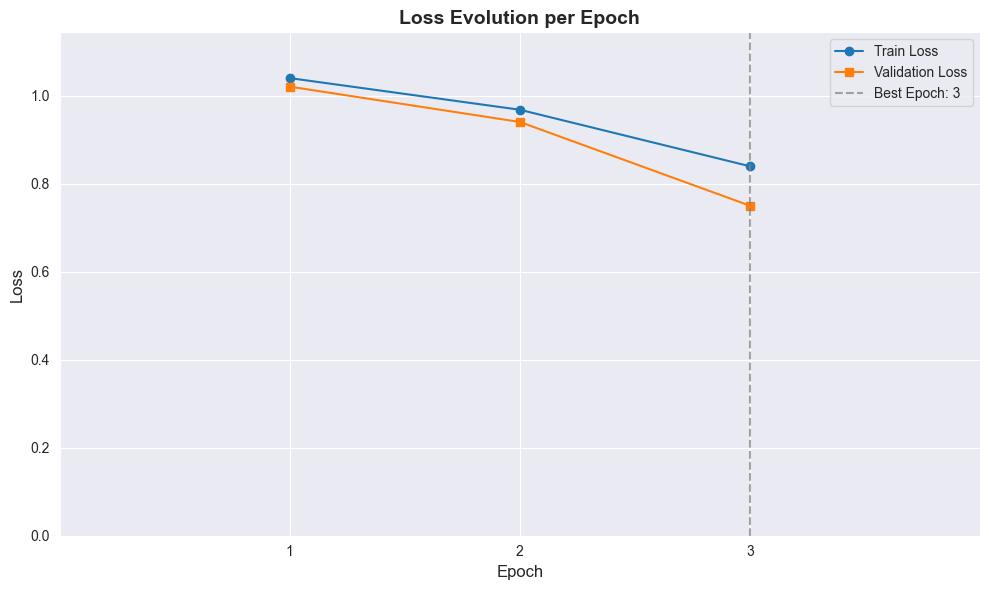

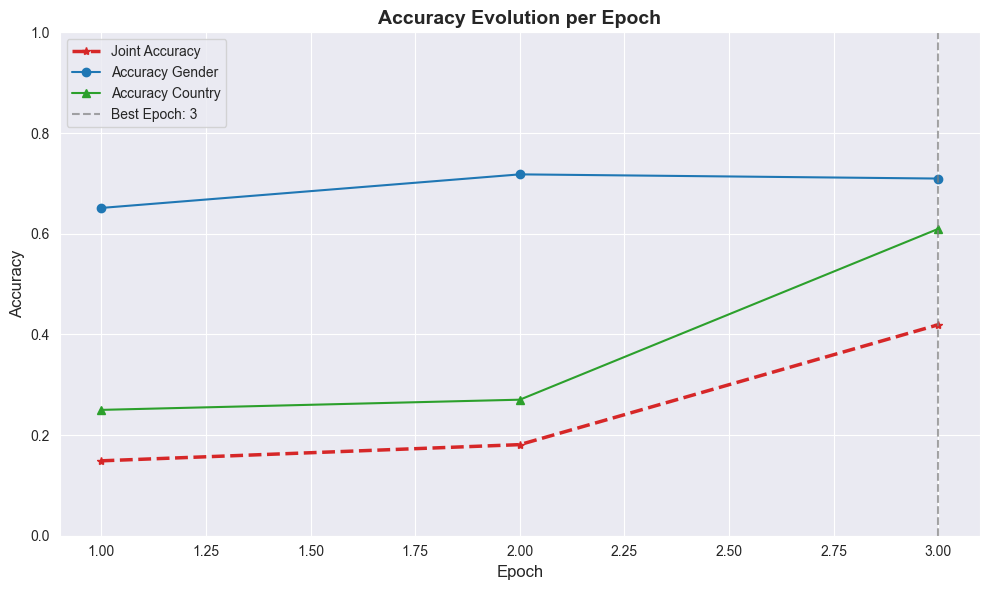

In [14]:
trainer.print_training_summary()
trainer.plot_loss()
trainer.plot_accuracy()

# Results

Evaluating on Evaluation Set:


Evaluation... :   2%|▏         | 2/105 [00:01<00:52,  1.97it/s]

Evaluation... : 100%|██████████| 105/105 [00:14<00:00,  7.06it/s]


Loss             : 0.8768
Joint Accuracy   : 0.4190
Accuracy Gender  : 0.7095
Accuracy Country : 0.6095

 Classification Report (Gender):
              precision    recall  f1-score   support

      female       0.82      0.54      0.65       420
        male       0.66      0.88      0.75       420

    accuracy                           0.71       840
   macro avg       0.74      0.71      0.70       840
weighted avg       0.74      0.71      0.70       840


 Classification Report (Country):
              precision    recall  f1-score   support

   argentina       0.78      0.45      0.57       120
       chile       0.49      0.36      0.42       120
    colombia       0.69      0.64      0.67       120
      mexico       0.60      0.72      0.66       120
        peru       0.73      0.57      0.64       120
       spain       0.47      0.81      0.59       120
   venezuela       0.67      0.71      0.69       120

    accuracy                           0.61       840
   macro avg

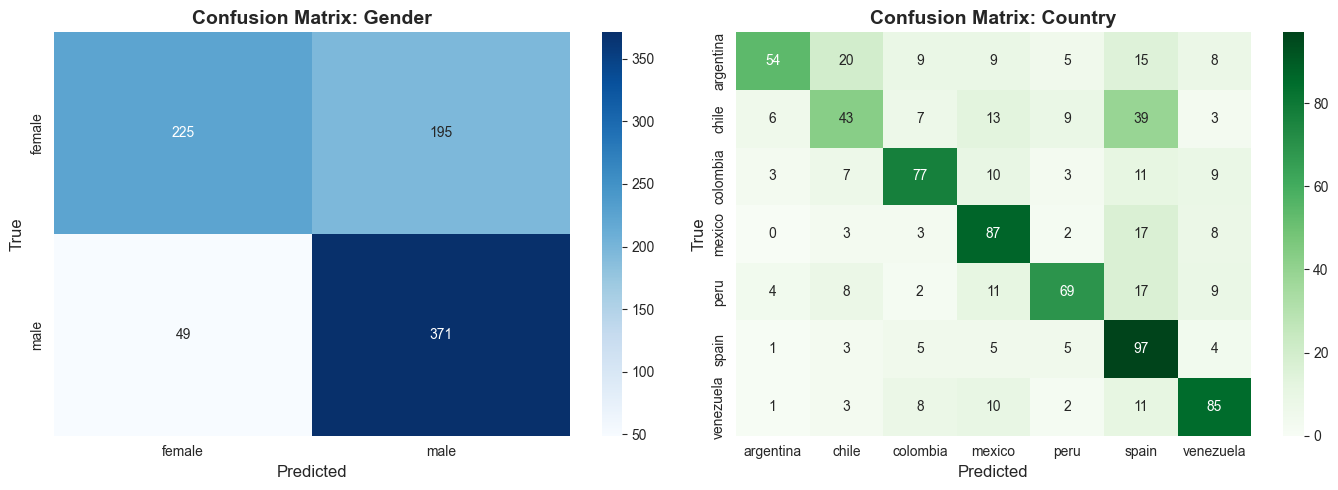

In [15]:
class Evaluation:
    @staticmethod
    def plot_confusion_matrices(y_true_gender: List[int], y_pred_gender: List[int], labels_gender: List[str],
                                y_true_country: List[int], y_pred_country: List[int], labels_country: List[str]) -> None:
        """
        Display side-by-side confusion matrices for gender and country classification.

        Parameters
        ----------
        y_true_gender : list or array
            True gender labels.
        y_pred_gender : list or array
            Predicted gender labels.
        labels_gender : list of str
            Class names for gender.
        y_true_country : list or array
            True country labels.
        y_pred_country : list or array
            Predicted country labels.
        labels_country : list of str
            Class names for country.
        """
        fig, axes = plt.subplots(1, 2, figsize = (14, 5))

        # Gender confusion matrix
        cm_gender = confusion_matrix(y_true_gender, y_pred_gender)
        sns.heatmap(cm_gender, annot = True, fmt = 'd', cmap = 'Blues',
                    xticklabels = labels_gender, yticklabels = labels_gender, ax = axes[0])
        axes[0].set_title("Confusion Matrix: Gender", fontsize = 14, weight = 'bold')
        axes[0].set_xlabel("Predicted", fontsize = 12)
        axes[0].set_ylabel("True", fontsize = 12)

        # Country confusion matrix
        cm_country = confusion_matrix(y_true_country, y_pred_country)
        sns.heatmap(cm_country, annot = True, fmt = 'd', cmap = 'Greens',
                    xticklabels = labels_country, yticklabels = labels_country, ax = axes[1])
        axes[1].set_title("Confusion Matrix: Country", fontsize = 14, weight = 'bold')
        axes[1].set_xlabel("Predicted", fontsize = 12)
        axes[1].set_ylabel("True", fontsize = 12)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def evaluate_dataset(trainer: Trainer, dataloader: DataLoader) -> dict:
        """
        Evaluates the model on a given Validation dataloader and prints summary of accuracy,
        classification reports, and confusion matrices.

        Parameters
        ----------
        trainer : Trainer
            The Trainer object containing the model and evaluation methods.
        dataloader : DataLoader
            The DataLoader object for the dataset to be evaluated.

        Returns
        -------
        results : dict
            A dictionary containing the evaluation results, including loss, accuracy, and predictions.
        """
        print(f"Evaluating on Evaluation Set:")
        results = trainer.eval_model(dataloader)

        # Print metrics
        print(f"Loss             : {results['loss_val']:.4f}")
        print(f"Joint Accuracy   : {results['joint_accuracy']:.4f}")
        print(f"Accuracy Gender  : {results['accuracy_gender']:.4f}")
        print(f"Accuracy Country : {results['accuracy_country']:.4f}")

        # Recover class labels
        labels_gender = [label for label, _ in sorted(trainer.train_dataset.gender_to_id.items(), key = lambda x: x[1])]
        labels_country = [label for label, _ in sorted(trainer.train_dataset.country_to_id.items(), key = lambda x: x[1])]

        print("\n Classification Report (Gender):")
        print(classification_report(results['targets_gender'], results['preds_gender'], target_names = labels_gender))

        print("\n Classification Report (Country):")
        print(classification_report(results['targets_country'], results['preds_country'], target_names = labels_country))

        Evaluation.plot_confusion_matrices(
            results['targets_gender'], results['preds_gender'], labels_gender,
            results['targets_country'], results['preds_country'], labels_country
        )

        return results

val_results = Evaluation.evaluate_dataset(trainer, val_dataloader)

# Predictions

In [16]:
class TestPredictor:
    def __init__(self, trainer: Trainer, dataset: Dataset, dataloader: DataLoader):
        self.model = trainer.model
        self.dataset = dataset
        self.dataloader = dataloader
        self.device = trainer.device
        self.id_to_gender = dataset.id_to_gender
        self.id_to_country = dataset.id_to_country
        self.predictions = self.predict()

    def predict(self) -> List[Tuple[str, str]]:
        self.model.eval()
        predictions = []

        with torch.no_grad():
            # Iterate over the batches.
            for inputs, user_ids in tqdm(self.dataloader, desc = "Predicting...", colour = "cyan"):
                inputs = inputs.to(self.device)

                # Forward pass.
                logits_gender, logits_country, _, _ = self.model(inputs)

                # Predictions and targets.
                predictions_gender = logits_gender.argmax(dim = 1).cpu().tolist()     # Predicted class for gender.
                predictions_countries = logits_country.argmax(dim = 1).cpu().tolist() # Predicted class for country.

                for user_id, pred_gender, pred_country in zip(user_ids, predictions_gender, predictions_countries):
                    label_gender = self.id_to_gender[pred_gender]
                    label_country = self.id_to_country[pred_country]
                    predictions.append((user_id, f"{label_gender}:::{label_country}"))

        return predictions

    def save_predictions_csv(self, output_file = "predictions.csv"):
        with open(output_file, mode = 'w', newline = '', encoding = 'utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(["Id", "Gender:::Nationality"])
            for user_id, label in self.predictions:
                writer.writerow([user_id, label])

In [17]:
predictor = TestPredictor(
    trainer       = trainer,
    dataset       = test_dataset,
    dataloader    = test_dataloader,
)
predictor.save_predictions_csv(output_file = "predictions.csv")

Predicting...: 100%|██████████| 350/350 [00:43<00:00,  8.02it/s]


In [28]:
import csv

# 1. Cargar el archivo de predicciones con el formato Id,Gender:::Country
pred_dict = {}
with open("predictions.csv", mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        gender, country = row["Gender:::Nationality"].split(":::")
        pred_dict[row["Id"]] = (gender, country)

# 2. Crear diccionario de predicción por reseña
tweet_to_pred = {}
for user_id, tweet in data_test:
    if user_id in pred_dict:
        tweet_to_pred[(user_id, tweet)] = pred_dict[user_id]
    else:
        tweet_to_pred[(user_id, tweet)] = ("_", "_")  # o puedes omitirlo si prefieres

# Opcional: inspeccionar
#list(tweet_to_pred.items())[:3]

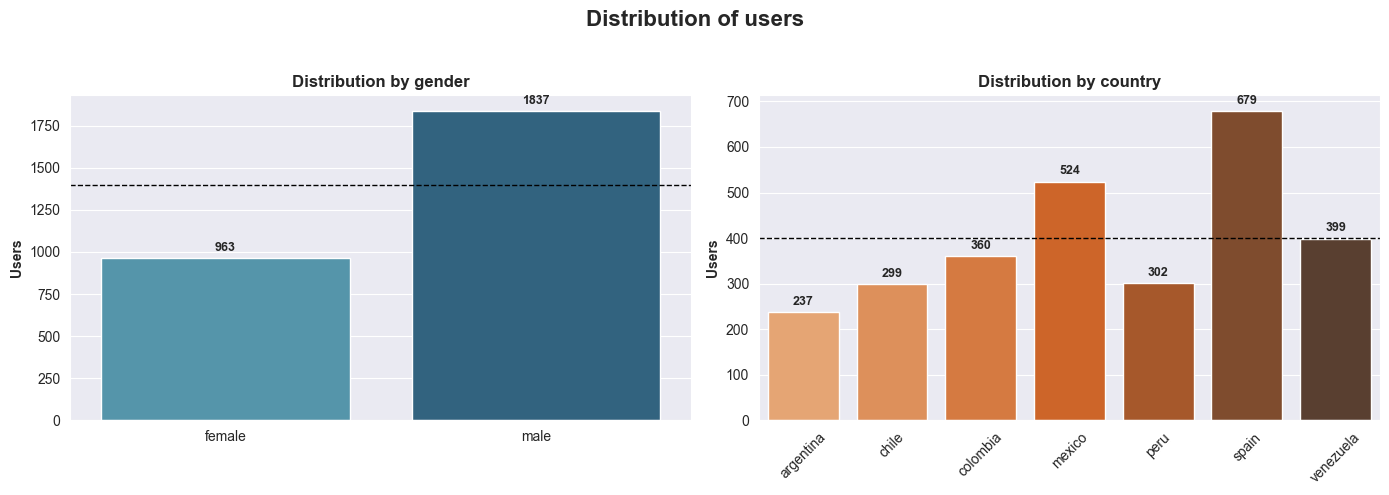

In [35]:
def annotate_bars(ax):
    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        xy = (bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom', fontsize=9, weight='bold')

# Leer CSV ignorando cabecera si describe estructura
df = pd.read_csv("predictions.csv", header=None, names=["user_id", "label"], skiprows=1)
df[['gender', 'country']] = df['label'].str.split(':::', expand=True)

# Contar por género y país
gender_counts = df["gender"].value_counts().reindex(["female", "male"])
country_order = sorted(df["country"].unique())
country_counts = df["country"].value_counts().reindex(country_order)

# Crear figura
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of users', fontsize=16, weight='bold')

# Gráfico de género
sns.barplot(x=gender_counts.index, y=gender_counts.values,
            hue=gender_counts.index, ax=axs[0], palette="YlGnBu_d", legend=False)
axs[0].axhline(y = 1400, color = 'k', linestyle = '--', linewidth = 1)
axs[0].set_title("Distribution by gender", fontsize=12, weight='bold')
axs[0].set_ylabel("Users", weight='bold')
axs[0].set_xlabel("", weight='bold')
annotate_bars(axs[0])

# Gráfico de país
sns.barplot(x=country_counts.index, y=country_counts.values,
            hue=country_counts.index, ax=axs[1], palette='Oranges_d', legend=False)
axs[1].axhline(y = 400, color = 'k', linestyle = '--', linewidth = 1)
axs[1].set_title("Distribution by country", fontsize=12, weight='bold')
axs[1].set_ylabel("Users", weight='bold')
axs[1].set_xlabel("", weight='bold')
axs[1].tick_params(axis='x', rotation=45)
annotate_bars(axs[1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()